In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("store_sales.csv")
df.head()

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
0,1,58,Female,Accessories,Handbag,115.50,Autumn,Card,3.5,18,4
1,2,40,Male,Mens Clothing,Shirt,103.43,Spring,Card,4.1,13,4
2,3,66,Female,Sports,Football,35.45,Spring,Card,3.3,11,3
3,4,39,Female,Accessories,Handbag,153.31,Spring,Card,4.4,13,4
4,5,23,Female,Home,Curtains,151.43,Winter,Card,4.1,20,10


In [7]:
df.tail()

,CustomerID,Age,Gender,Category,ItemPurchased,Amount,Season,PaymentMethod,ItemRating,DiscountApplied(%),PreviousPurchases
4995,4996,44,Female,Accessories,Sunglasses,172.64,Winter,Card,3.6,20,5
4996,4997,59,Male,Groceries,Beverages,54.00,Spring,Cash on Delivery,3.8,14,2
4997,4998,41,Female,Accessories,Handbag,159.33,Autumn,Card,4.3,26,8
4998,4999,63,Female,Womens Clothing,Skirt,173.82,Autumn,Card,4.8,26,8
4999,5000,41,Female,Footwear,Sandals,55.39,Autumn,Cash on Delivery,4.1,19,7


In [8]:
df.shape

(5000, 11)

In [9]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Category', 'ItemPurchased', 'Amount',
       'Season', 'PaymentMethod', 'ItemRating', 'DiscountApplied(%)',
       'PreviousPurchases'],
      dtype='str')

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Gender              5000 non-null   str    
 3   Category            5000 non-null   str    
 4   ItemPurchased       5000 non-null   str    
 5   Amount              5000 non-null   float64
 6   Season              5000 non-null   str    
 7   PaymentMethod       5000 non-null   str    
 8   ItemRating          5000 non-null   float64
 9   DiscountApplied(%)  5000 non-null   int64  
 10  PreviousPurchases   5000 non-null   int64  
dtypes: float64(2), int64(4), str(5)
memory usage: 429.8 KB


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

CustomerID            0
Age                   0
Gender                0
Category              0
ItemPurchased         0
Amount                0
Season                0
PaymentMethod         0
ItemRating            0
DiscountApplied(%)    0
PreviousPurchases     0
dtype: int64

In [13]:
# Numerical Columns
num_cols= df.select_dtypes(include=[np.number]).drop(columns='CustomerID').columns.to_list()
print(num_cols)

['Age', 'Amount', 'ItemRating', 'DiscountApplied(%)', 'PreviousPurchases']


In [14]:
# Calculate descriptive statistics
 
stats=pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Mode': df[num_cols].mode().iloc[0],
    'Std Dev': df[num_cols].std()
})

print(stats)

                          Mean   Median   Mode     Std Dev
Age                  45.224800   45.000   42.0   14.564995
Amount              285.090522  122.485  108.5  551.454382
ItemRating            3.784160    3.800    3.8    0.681796
DiscountApplied(%)   14.983600   15.000   16.0    5.988063
PreviousPurchases     5.008800    5.000    5.0    2.194285


In [36]:
# Time series analysis: 
season_months = {
    'Spring': [3, 4, 5],
    'Summer': [6, 7, 8],
    'Autumn': [9, 10, 11],
    'Winter': [12, 1, 2]
}
df['Month_Num'] = df['Season'].map(season_months)
df['Month']=df['Month_Num'].apply(np.random.choice)


monthly= df.groupby(df['Month'],as_index=False)['Amount'].sum()
quarterly= df.groupby(df["Season"],as_index=False)['Amount'].sum()

monthly.head()


,Month,Amount
0,1,107046.13
1,2,131154.96
2,3,122546.86
3,4,126014.71
4,5,127467.83


<function matplotlib.pyplot.show(close=None, block=None)>

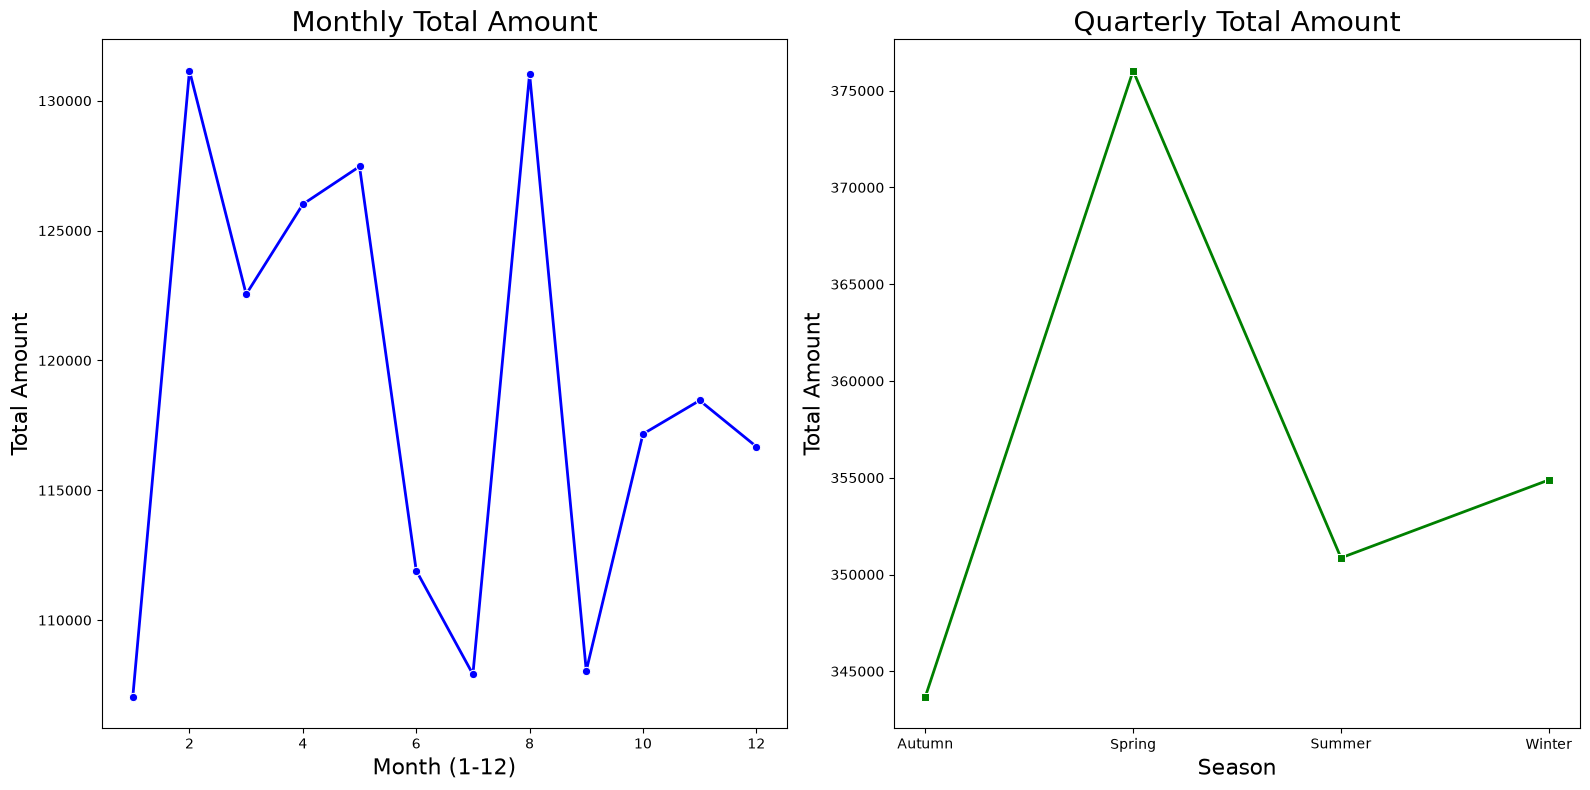

In [45]:
# line charts -> monthly and quarterly sales trends
fig, ax=plt.subplots(1,2,figsize=(16,8))

sns.lineplot(data=monthly, x='Month', y='Amount', marker='o', linewidth=2, color='blue', ax=ax[0] )
ax[0].set_title("Monthly Total Amount", fontsize=20)
ax[0].set_xlabel("Month (1-12)",fontsize=16)
ax[0].set_ylabel("Total Amount",fontsize=16)


sns.lineplot(data=quarterly, x='Season', y='Amount', marker='s', linewidth=2, color='green', ax=ax[1] )
ax[1].set_title("Quarterly Total Amount", fontsize=20)
ax[1].set_xlabel("Season",fontsize=16)
ax[1].set_ylabel("Total Amount",fontsize=16)

plt.tight_layout()
plt.show


